In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
numeric_col = df.select_dtypes(include="number").columns
numeric_col

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [6]:
# manual_mean
# Mean=∑x/n
def manual_mean(data):
    total =0
    count =0

    for value in data:
        if pd.notna(value):
            total+=value
            count+=1

    return total/count

In [19]:
# manual_median
# If the number of values is odd → middle value
# If even → average of two middle values
def manual_median(data):
    values = []

    for value in data:
        if pd.notna(value):
            values.append(value)

    # Manual sorting
    for i in range(len(values)):
        for j in range(i + 1, len(values)):
            if values[i] > values[j]:
                values[i], values[j] = values[j], values[i]

    n = len(values)

    if n % 2 == 1:
        return values[n // 2]
    else:
        return (values[n // 2 - 1] + values[n // 2]) / 2

In [20]:
# Manual Mode

# Count how many times each value occurs.

def manual_mode(data):
    frequency = {}

    for value in data:
        if pd.notna(value):
            if value in frequency:
                frequency[value] +=1
            else:
                frequency[value] =1

    
    mode_value = None
    highest_frequency = 0

    for value in frequency:
            if frequency[value] > highest_frequency:
                highest_frequency = frequency[value]
                mode_value = value
    return mode_value    

In [21]:
def manual_min(data):
    first = True

    for value in data:
        if pd.notna(value):
            if first:
                minimum = value
                first = False
            elif value < minimum:
                minimum = value

    return minimum

In [22]:
def manual_max(data):
    first = True

    for value in data:
        if pd.notna(value):
            if first:
                maximum = value
                first = False
            elif value > maximum:
                maximum = value

    return maximum

In [23]:
def manual_std(data):
    values = []

    for value in data:
        if pd.notna(value):
            values.append(value)

    mean = manual_mean(values)

    squared_sum = 0

    for value in values:
        difference = value - mean
        squared_sum += difference ** 2

    variance = squared_sum / len(values)

    return variance ** 0.5

In [24]:
results = {}

for column in numeric_col:
    data = df[column]

    results[column] = {
        "Mean": manual_mean(data),
        "Median": manual_median(data),
        "Mode": manual_mode(data),
        "Min": manual_min(data),
        "Max": manual_max(data),
        "Std": manual_std(data)
    }

In [31]:
summary = pd.DataFrame(results).T

print(summary)

                Mean  Median   Mode    Min    Max        Std
age        54.434146    56.0   58.0   29.0   77.0   9.067864
sex         0.695610     1.0    1.0    0.0    1.0   0.460149
cp          0.942439     1.0    0.0    0.0    3.0   1.029138
trestbps  131.611707   130.0  120.0   94.0  200.0  17.508171
chol      246.000000   240.0  204.0  126.0  564.0  51.567337
fbs         0.149268     0.0    0.0    0.0    1.0   0.356353
restecg     0.529756     1.0    1.0    0.0    2.0   0.527620
thalach   149.114146   152.0  162.0   71.0  202.0  22.994499
exang       0.336585     0.0    0.0    0.0    1.0   0.472542
oldpeak     1.071512     0.8    0.0    0.0    6.2   1.174480
slope       1.385366     1.0    1.0    0.0    2.0   0.617454
ca          0.754146     0.0    0.0    0.0    4.0   1.030295
thal        2.323902     2.0    2.0    0.0    3.0   0.620357
target      0.513171     1.0    1.0    0.0    1.0   0.499827


In [32]:
display(summary)

,Mean,Median,Mode,Min,Max,Std
age,54.434146,56.0,58.0,29.0,77.0,9.067864
sex,0.695610,1.0,1.0,0.0,1.0,0.460149
cp,0.942439,1.0,0.0,0.0,3.0,1.029138
trestbps,131.611707,130.0,120.0,94.0,200.0,17.508171
chol,246.000000,240.0,204.0,126.0,564.0,51.567337
fbs,0.149268,0.0,0.0,0.0,1.0,0.356353
restecg,0.529756,1.0,1.0,0.0,2.0,0.527620
thalach,149.114146,152.0,162.0,71.0,202.0,22.994499
exang,0.336585,0.0,0.0,0.0,1.0,0.472542
oldpeak,1.071512,0.8,0.0,0.0,6.2,1.174480


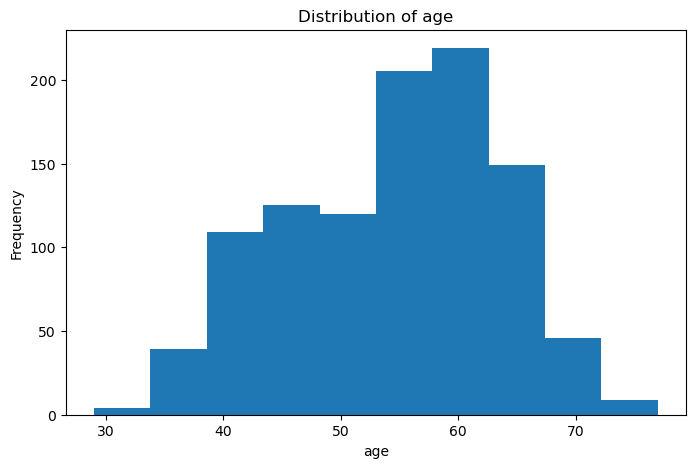

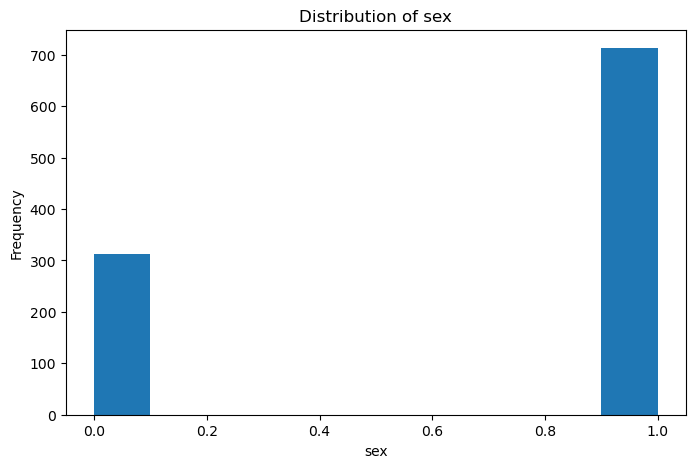

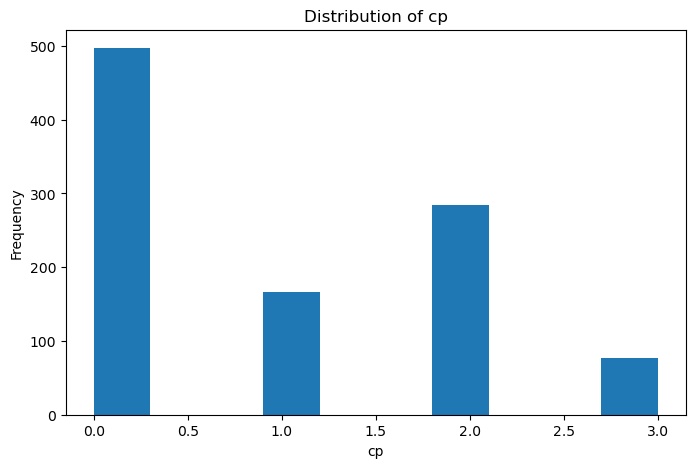

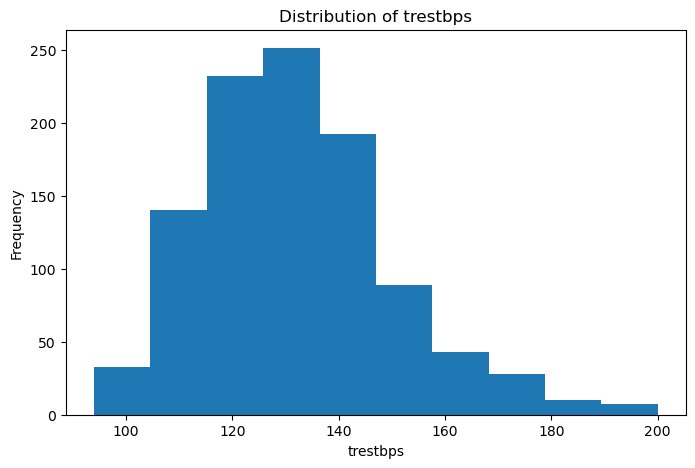

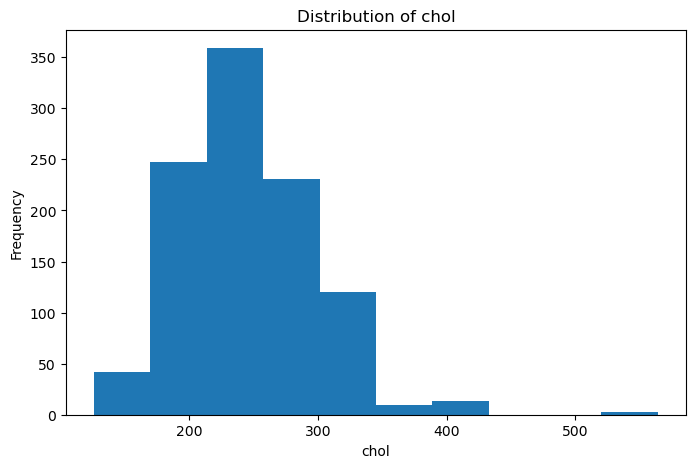

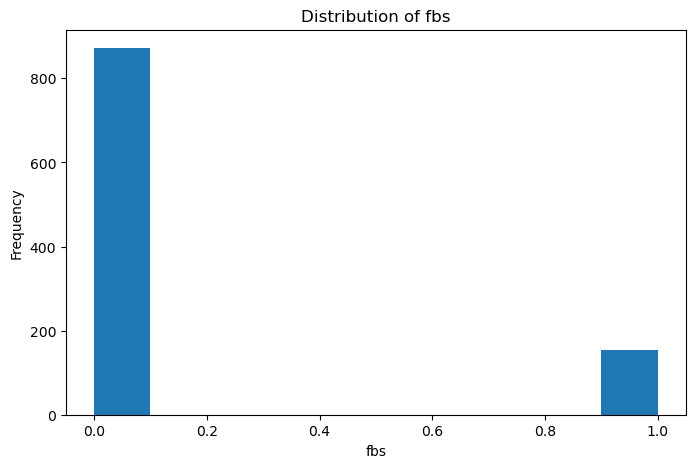

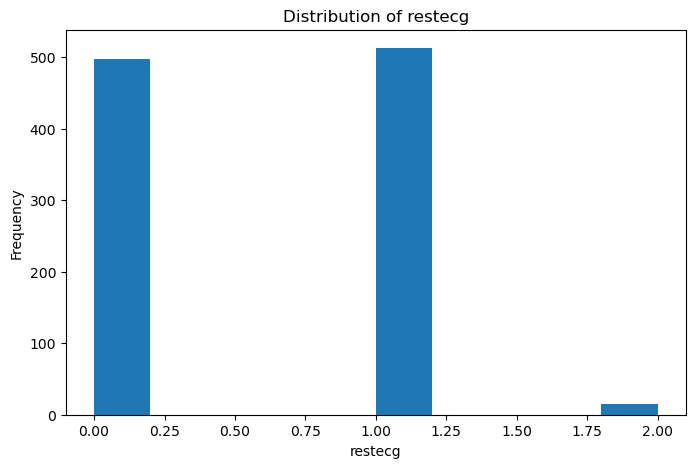

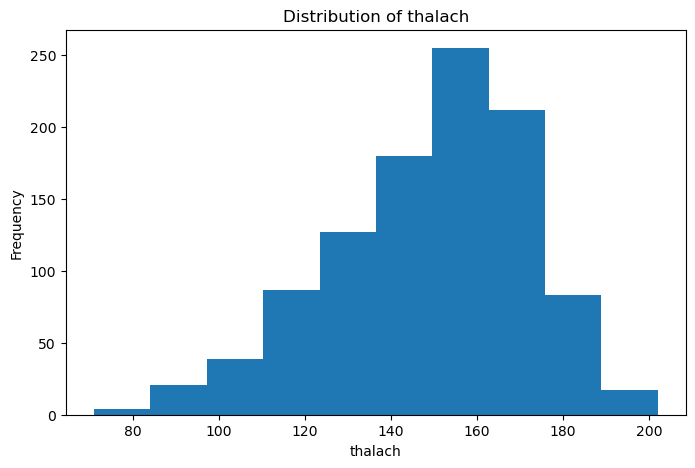

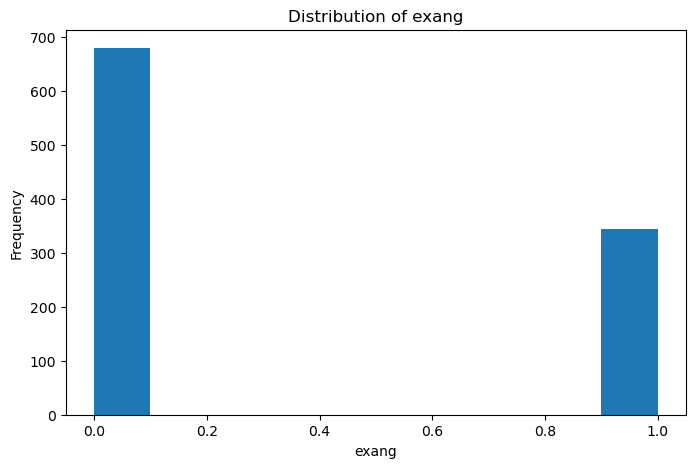

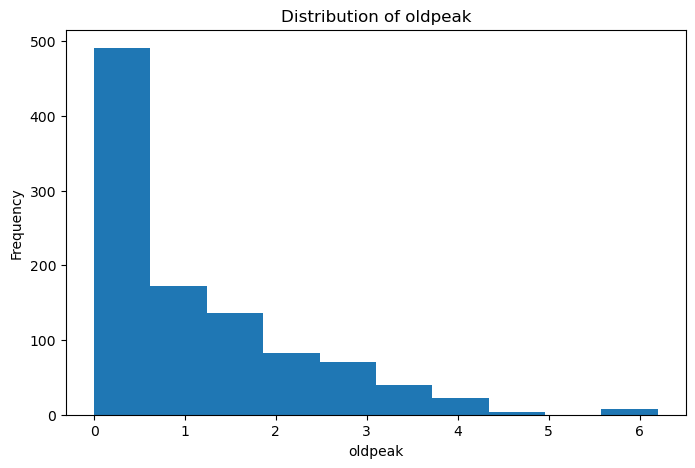

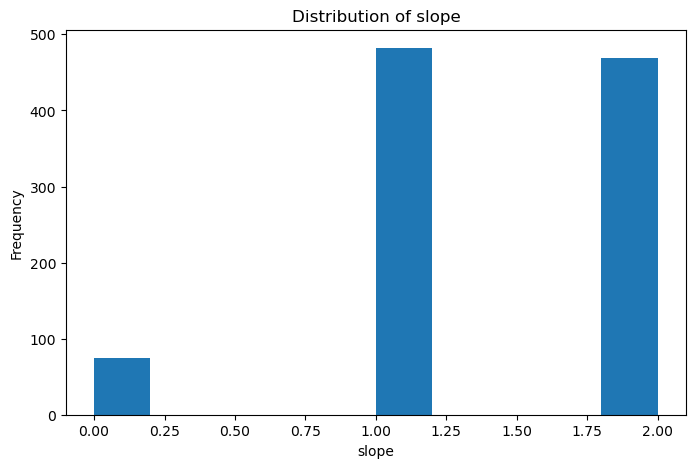

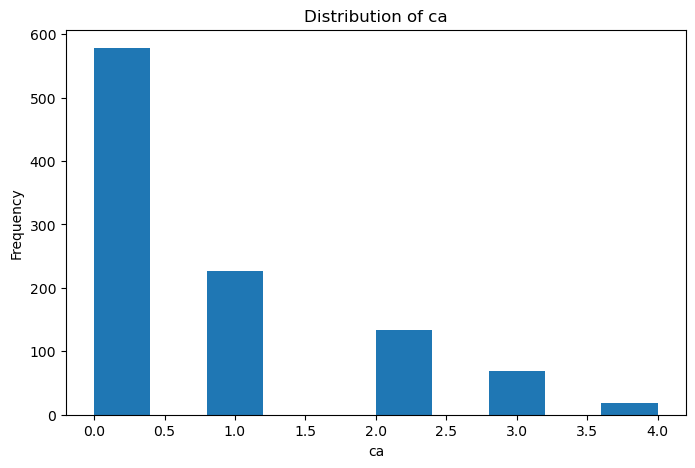

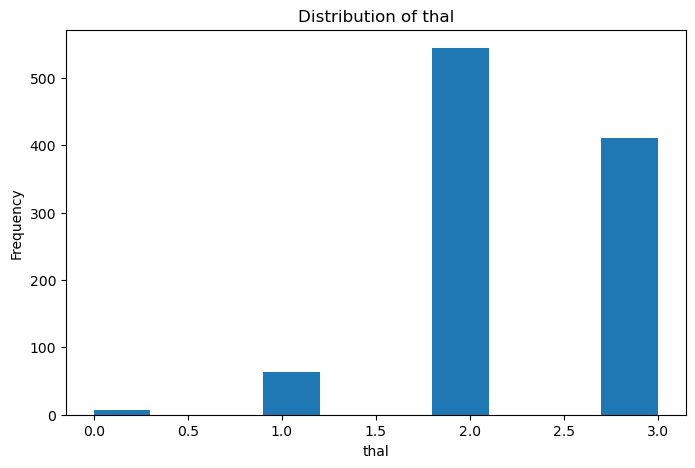

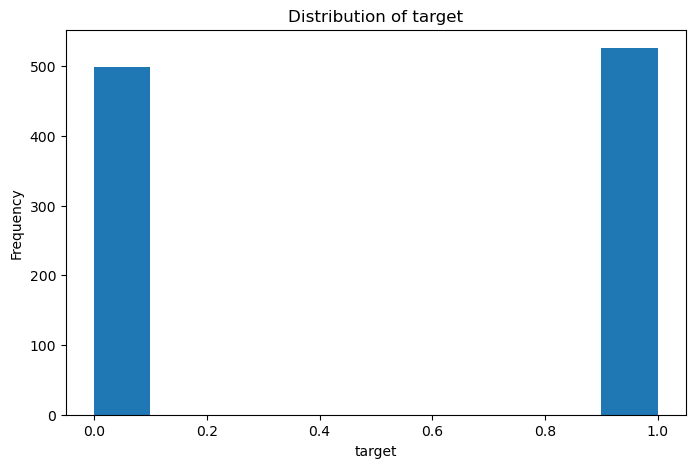

In [35]:
import matplotlib.pyplot as plt
for column in numeric_col:
    plt.figure(figsize=(8, 5))

    plt.hist(df[column].dropna(), bins=10)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()